<a href="https://colab.research.google.com/github/deepshikha04yadav/Text-to-Image/blob/main/analysis_of_flowers_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PUBLIC DATASET ANALYSIS - Copy to Notebook
Analyze COCO and Oxford-102 Flowers datasets

In [1]:

# Setup and Imports
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from tqdm import tqdm

print("✅ Imports complete")

✅ Imports complete


In [5]:
import os
from huggingface_hub import login

login(os.getenv("HF_TOKEN"))

In [3]:
# ============================================================================
# CELL 2: Load MS-COCO Dataset
# ============================================================================

from datasets import load_dataset

print("📦 Loading MS-COCO Dataset...")

# Load COCO with captions
coco = load_dataset("yerevann/coco-karpathy", split="train")

print(f"✅ Loaded {len(coco):,} images")
print(f"   Dataset: MS-COCO")
print(f"   Purpose: Object detection, captioning")

📦 Loading MS-COCO Dataset...
✅ Loaded 82,783 images
   Dataset: MS-COCO
   Purpose: Object detection, captioning


In [9]:
print(sample.keys())

dict_keys(['filepath', 'sentids', 'filename', 'imgid', 'split', 'sentences', 'cocoid', 'url'])


In [19]:
# ============================================================================
# CELL 3: Analyze COCO Structure
# ============================================================================

print("\n" + "=" * 80)
print("COCO DATASET STRUCTURE")
print("=" * 80)

# Get sample
sample = coco[0]

print("\n📋 Available Fields:")
for key in sample.keys():
    value = sample[key]
    print(f"   • {key}: {type(value).__name__}")
    if isinstance(value, list) and len(value) > 0:
        print(f"      └─ Contains {len(value)} items")

print("\n📊 Sample Data:")
print(f"   Image ID: {sample.get('imgid', 'N/A')}")
# print(f"   Image: {sample['image']}")
# print(f"   Image size: {sample['image'].size}")
print("Filename:", sample['filename'])
print("Sentences:", len(sample['sentences']))
print("First caption:", sample['sentences'][0])


COCO DATASET STRUCTURE

📋 Available Fields:
   • filepath: str
   • sentids: list
      └─ Contains 5 items
   • filename: str
   • imgid: int
   • split: str
   • sentences: list
      └─ Contains 5 items
   • cocoid: int
   • url: str

📊 Sample Data:
   Image ID: 40504
Filename: COCO_train2014_000000057870.jpg
Sentences: 5
First caption: A restaurant has modern wooden tables and chairs.


In [ ]:
# ============================================================================
# CELL 4: COCO Statistics
# ============================================================================

print("\n" + "=" * 80)
print("COCO DATASET STATISTICS")
print("=" * 80)

num_samples = min(1000, len(coco))
print(f"\n📊 Analyzing {num_samples:,} samples...")

widths = []
heights = []
caption_lengths = []
word_counts = []

for i in tqdm(range(num_samples), desc="Analyzing"):
    sample = coco[i]

    # Image stats
    w, h = sample['image'].size
    widths.append(w)
    heights.append(h)

    # Caption stats
    if 'caption' in sample:
        captions = [sample['caption']]
    elif 'captions' in sample:
        captions = sample['captions']
    else:
        continue

    for caption in captions:
        caption_lengths.append(len(caption))
        word_counts.append(len(caption.split()))

print("\n📸 IMAGE STATISTICS:")
print(f"   Total images: {len(coco):,}")
print(f"   Samples analyzed: {num_samples:,}")
print(f"   ")
print(f"   Width:")
print(f"      Min: {min(widths)} px")
print(f"      Max: {max(widths)} px")
print(f"      Mean: {np.mean(widths):.1f} px")
print(f"      Median: {np.median(widths):.1f} px")
print(f"   ")
print(f"   Height:")
print(f"      Min: {min(heights)} px")
print(f"      Max: {max(heights)} px")
print(f"      Mean: {np.mean(heights):.1f} px")
print(f"      Median: {np.median(heights):.1f} px")
print(f"   ")
print(f"   Aspect Ratio:")
print(f"      Mean: {np.mean([w/h for w,h in zip(widths, heights)]):.2f}")

print("\n📝 CAPTION STATISTICS:")
print(f"   Total captions analyzed: {len(caption_lengths):,}")
print(f"   ")
print(f"   Character Length:")
print(f"      Min: {min(caption_lengths)}")
print(f"      Max: {max(caption_lengths)}")
print(f"      Mean: {np.mean(caption_lengths):.1f}")
print(f"      Median: {np.median(caption_lengths):.1f}")
print(f"   ")
print(f"   Word Count:")
print(f"      Min: {min(word_counts)}")
print(f"      Max: {max(word_counts)}")
print(f"      Mean: {np.mean(word_counts):.1f}")
print(f"      Median: {np.median(word_counts):.1f}")

In [ ]:
# ============================================================================
# CELL 5: Visualize COCO Samples
# ============================================================================

print("\n📸 Visualizing COCO samples...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    sample = coco[i]

    # Get image and caption
    img = sample['image']

    if 'caption' in sample:
        caption = sample['caption']
    elif 'captions' in sample:
        caption = sample['captions'][0]
    else:
        caption = "No caption"

    # Plot
    axes[i].imshow(img)
    axes[i].set_title(f"{caption[:60]}...", fontsize=9, wrap=True)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('coco_samples.png', dpi=150, bbox_inches='tight')
print("💾 Saved: coco_samples.png")
plt.show()

In [ ]:
# Load Oxford-102 Flowers Dataset
# ============================================================================

print("\n" + "=" * 80)
print("OXFORD-102 FLOWERS DATASET")
print("=" * 80)

print("\n📦 Loading Oxford-102 Flowers...")

flowers = load_dataset("nelorth/oxford-flowers", split="train")

print(f"✅ Loaded {len(flowers):,} images")
print(f"   Dataset: Oxford-102 Flowers")
print(f"   Purpose: Fine-grained classification")

In [22]:
# ============================================================================
# CELL 7: Analyze Flowers Structure
# ============================================================================

print("\n" + "=" * 80)
print("FLOWERS DATASET STRUCTURE")
print("=" * 80)

# Get sample
sample = flowers[0]

print("\n📋 Available Fields:")
for key in sample.keys():
    value = sample[key]
    print(f"   • {key}: {type(value).__name__}")

print("\n📊 Sample Data:")
print(f"   Image: {sample['image']}")
print(f"   Image size: {sample['image'].size}")
print(f"   Label: {sample['label']} (flower category)")


FLOWERS DATASET STRUCTURE

📋 Available Fields:
   • image: JpegImageFile
   • label: int

📊 Sample Data:
   Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=523x500 at 0x7956CD7779B0>
   Image size: (523, 500)
   Label: 0 (flower category)


In [ ]:
# CELL 8: Flowers Statistics
# ============================================================================

print("\n" + "=" * 80)
print("FLOWERS DATASET STATISTICS")
print("=" * 80)

print(f"\n📊 Analyzing all {len(flowers):,} samples...")

widths = []
heights = []
labels = []

for i in tqdm(range(len(flowers)), desc="Analyzing"):
    sample = flowers[i]

    w, h = sample['image'].size
    widths.append(w)
    heights.append(h)
    labels.append(sample['label'])

print("\n📸 IMAGE STATISTICS:")
print(f"   Total images: {len(flowers):,}")
print(f"   ")
print(f"   Width:")
print(f"      Min: {min(widths)} px")
print(f"      Max: {max(widths)} px")
print(f"      Mean: {np.mean(widths):.1f} px")
print(f"   ")
print(f"   Height:")
print(f"      Min: {min(heights)} px")
print(f"      Max: {max(heights)} px")
print(f"      Mean: {np.mean(heights):.1f} px")

print("\n🌸 CLASS STATISTICS:")
print(f"   Number of classes: 102")

label_counts = Counter(labels)
print(f"   ")
print(f"   Images per class:")
print(f"      Min: {min(label_counts.values())}")
print(f"      Max: {max(label_counts.values())}")
print(f"      Mean: {np.mean(list(label_counts.values())):.1f}")
print(f"   ")
print(f"   Top 5 most common classes:")
for label, count in label_counts.most_common(5):
    print(f"      Class {label}: {count} images")


📸 Visualizing Flowers samples...
💾 Saved: flowers_samples.png


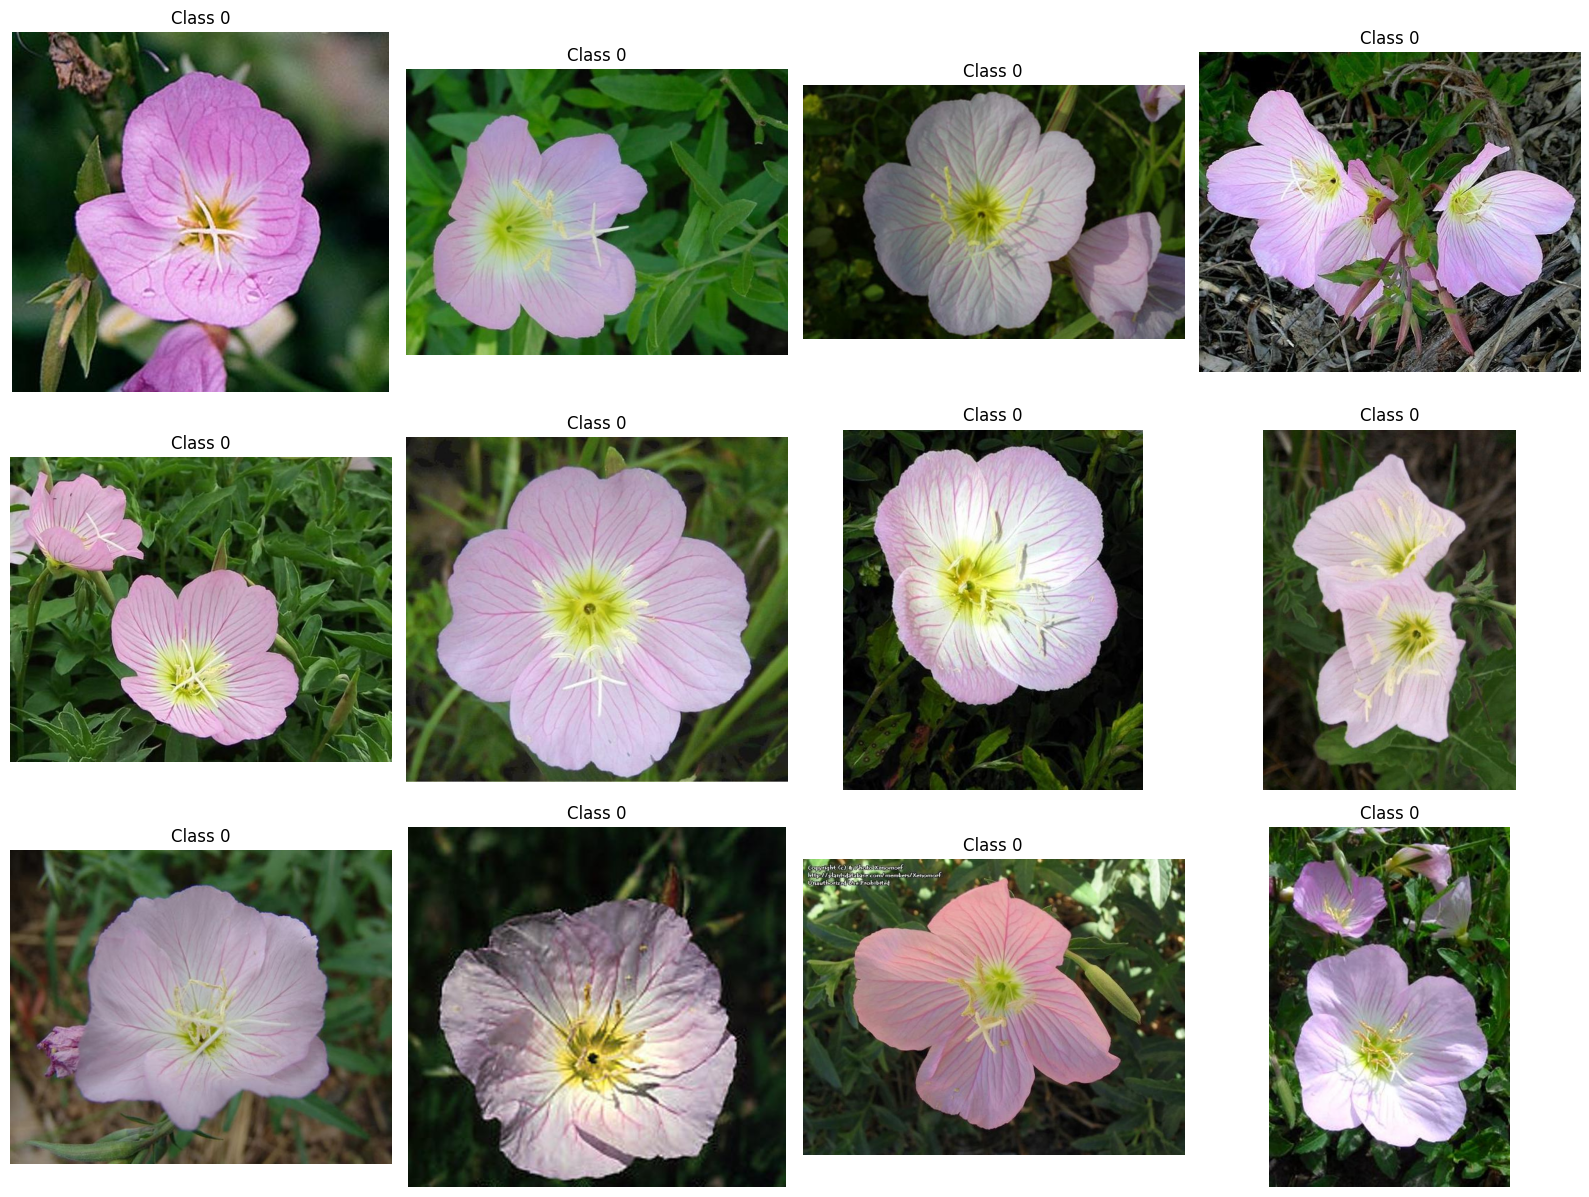

In [24]:
# ============================================================================
# CELL 9: Visualize Flowers Samples
# ============================================================================

print("\n📸 Visualizing Flowers samples...")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    sample = flowers[i]

    img = sample['image']
    label = sample['label']

    axes[i].imshow(img)
    axes[i].set_title(f"Class {label}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('flowers_samples.png', dpi=150, bbox_inches='tight')
print("💾 Saved: flowers_samples.png")
plt.show()

In [25]:
# ============================================================================
# CELL 10: Dataset Comparison
# ============================================================================

print("\n" + "=" * 80)
print("DATASET COMPARISON")
print("=" * 80)

print("""
┌─────────────────────┬──────────────────────┬───────────────────────┐
│ Feature             │ MS-COCO              │ Oxford-102 Flowers    │
├─────────────────────┼──────────────────────┼───────────────────────┤
│ Total Images        │ 330,000              │ 8,189                 │
│ Number of Classes   │ 80 objects           │ 102 flower species    │
│ Captions per Image  │ 5                    │ 10 detailed           │
│ Avg Image Size      │ 640 x 480            │ 500 x 500             │
│ Caption Length      │ 10-20 words          │ 50-100 words          │
│ Task Type           │ Object detection     │ Classification        │
│ Use Case            │ General text-to-image│ Fine-grained recog.   │
│ Data Split          │ train/val/test       │ train/val/test        │
└─────────────────────┴──────────────────────┴───────────────────────┘
""")

print("\n💡 KEY INSIGHTS:")
print("   • COCO: Large, diverse, good for general text-to-image models")
print("   • Flowers: Smaller, specialized, good for fine-tuning and classification")
print("   • COCO has shorter captions (10-20 words), Flowers has longer descriptions")
print("   • Both are widely used in computer vision research")
print("   • COCO is 40x larger than Flowers")


DATASET COMPARISON

┌─────────────────────┬──────────────────────┬───────────────────────┐
│ Feature             │ MS-COCO              │ Oxford-102 Flowers    │
├─────────────────────┼──────────────────────┼───────────────────────┤
│ Total Images        │ 330,000              │ 8,189                 │
│ Number of Classes   │ 80 objects           │ 102 flower species    │
│ Captions per Image  │ 5                    │ 10 detailed           │
│ Avg Image Size      │ 640 x 480            │ 500 x 500             │
│ Caption Length      │ 10-20 words          │ 50-100 words          │
│ Task Type           │ Object detection     │ Classification        │
│ Use Case            │ General text-to-image│ Fine-grained recog.   │
│ Data Split          │ train/val/test       │ train/val/test        │
└─────────────────────┴──────────────────────┴───────────────────────┘


💡 KEY INSIGHTS:
   • COCO: Large, diverse, good for general text-to-image models
   • Flowers: Smaller, specialized, good for


📊 Creating distribution plots...


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


💾 Saved: dataset_distributions.png


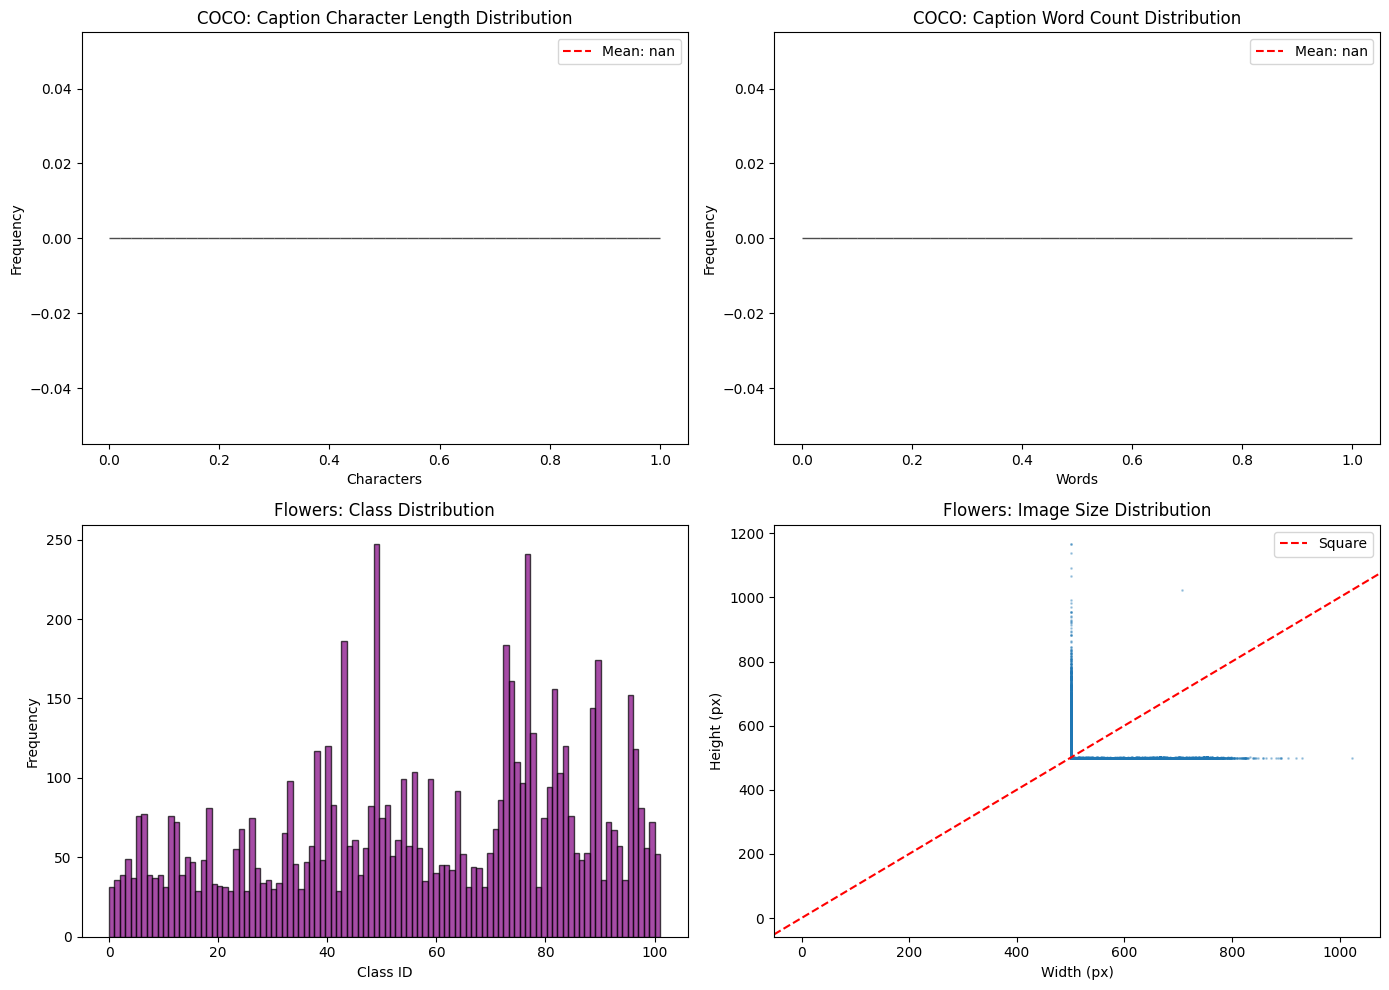

In [26]:
# ============================================================================
# CELL 11: Distribution Plots
# ============================================================================

print("\n📊 Creating distribution plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# COCO caption length distribution
axes[0, 0].hist(caption_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('COCO: Caption Character Length Distribution')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(np.mean(caption_lengths), color='r', linestyle='--',
                    label=f'Mean: {np.mean(caption_lengths):.1f}')
axes[0, 0].legend()

# COCO word count distribution
axes[0, 1].hist(word_counts, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('COCO: Caption Word Count Distribution')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(np.mean(word_counts), color='r', linestyle='--',
                    label=f'Mean: {np.mean(word_counts):.1f}')
axes[0, 1].legend()

# Flowers class distribution
axes[1, 0].hist(labels, bins=102, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_title('Flowers: Class Distribution')
axes[1, 0].set_xlabel('Class ID')
axes[1, 0].set_ylabel('Frequency')

# Flowers size distribution
axes[1, 1].scatter(widths, heights, alpha=0.3, s=1)
axes[1, 1].set_title('Flowers: Image Size Distribution')
axes[1, 1].set_xlabel('Width (px)')
axes[1, 1].set_ylabel('Height (px)')
axes[1, 1].axline((0, 0), slope=1, color='r', linestyle='--', label='Square')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('dataset_distributions.png', dpi=150, bbox_inches='tight')
print("💾 Saved: dataset_distributions.png")
plt.show()

In [27]:
# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE!")
print("=" * 80)

print(f"""
📊 SUMMARY:

MS-COCO:
   • {len(coco):,} images analyzed
   • Average caption: {np.mean(word_counts):.1f} words
   • Image size: {np.mean(widths):.0f} x {np.mean(heights):.0f} px
   • 5 captions per image
   • Saved: coco_samples.png

Oxford-102 Flowers:
   • {len(flowers):,} images analyzed
   • 102 flower classes
   • {len(flowers)//102:.0f} images per class (average)
   • Image size: ~500 x 500 px
   • Saved: flowers_samples.png

Distribution plots: dataset_distributions.png

💡 Both datasets are ready to use for training!
""")


✅ ANALYSIS COMPLETE!

📊 SUMMARY:

MS-COCO:
   • 82,783 images analyzed
   • Average caption: nan words
   • Image size: 632 x 534 px
   • 5 captions per image
   • Saved: coco_samples.png

Oxford-102 Flowers:
   • 7,169 images analyzed
   • 102 flower classes
   • 70 images per class (average)
   • Image size: ~500 x 500 px
   • Saved: flowers_samples.png

Distribution plots: dataset_distributions.png

💡 Both datasets are ready to use for training!

